# SaaS CHURN SIGNAL SYSTEM 🚀📊  

## Machine Learning + SHAP 🤖📉  

## NOTEBOOK OVERVIEW 📖  
This notebook builds a **churn prediction model**  that assigns every customer a probability score  between 0 and 1.  

- Score 0.9 = 90% likely to churn → act now ⚠️  
- Score 0.1 = 10% likely to churn → safe ✅  

---

## MODELS BUILT 🧠  
1. **Logistic Regression** — simple, interpretable  
2. **Random Forest** — stronger, handles non-linearity  

---

## EVALUATION METRICS 📊  
- **AUC-ROC**   : Overall model discrimination ability  
- **Precision** : Of predicted churners, how many actually churned?  
- **Recall**    : Of actual churners, how many did we catch?  
- **F1 Score**  : Balance between precision and recall  

---

## EXPLAINABILITY 🔍  
SHAP (SHapley Additive exPlanations) explains  
**WHY** each customer got their score — which features  
pushed the score up or down.  

---

# **Load data, encode categorical columns into numbers**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, classification_report,
    roc_curve, confusion_matrix,
    precision_recall_curve
)
import shap
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'shap'

In [ ]:

import os
os.makedirs('reports', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load and clean data
df = pd.read_csv('telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

# Feature engineering — convert categoricals to numbers
# Binary columns — Yes/No → 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                           'No phone service': 0,
                           'No internet service': 0})

# Gender — Male/Female → 1/0
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# Contract — ordinal encoding (longer = higher)
df['Contract'] = df['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

# Internet service — one hot encoding
df = pd.get_dummies(df, columns=['InternetService'], drop_first=True)

# Payment method — one hot encoding
df = pd.get_dummies(df, columns=['PaymentMethod'], drop_first=True)

# Final feature list
feature_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
    'InternetService_Fiber optic', 'InternetService_No',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

X = df[feature_cols]
y = df['Churn_Binary']

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print(f"\nChurn rate: {y.mean()*100:.2f}%")
print("\nFeatures used:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Feature matrix shape: (7032, 22)
Target distribution:
Churn_Binary
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.58%

Features used:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. MultipleLines
   8. OnlineSecurity
   9. OnlineBackup
  10. DeviceProtection
  11. TechSupport
  12. StreamingTV
  13. StreamingMovies
  14. Contract
  15. PaperlessBilling
  16. MonthlyCharges
  17. TotalCharges
  18. InternetService_Fiber optic
  19. InternetService_No
  20. PaymentMethod_Credit card (automatic)
  21. PaymentMethod_Electronic check
  22. PaymentMethod_Mailed check


# **Train/Test Split**
- Training set (80%) → used to ***teach*** the model

- Testing set (20%) → used to ***evaluate*** how well the model learned

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures same churn ratio in both splits
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)
print(f"\nChurn rate in training: {y_train.mean()*100:.2f}%")
print(f"Churn rate in testing : {y_test.mean()*100:.2f}%")

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nData split complete — ready for modeling")

Training set size: (5625, 22)
Testing set size : (1407, 22)

Churn rate in training: 26.58%
Churn rate in testing : 26.58%

Data split complete — ready for modeling


# **Logistic Regression (Baseline Model)**

In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred_class = lr_model.predict(X_test_scaled)

# Evaluation
lr_auc = roc_auc_score(y_test, lr_pred_proba)
print("=" * 45)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(f"AUC-ROC Score: {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred_class,
                            target_names=['Active', 'Churned']))



LOGISTIC REGRESSION RESULTS
AUC-ROC Score: 0.8359

Classification Report:
              precision    recall  f1-score   support

      Active       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



# Random Forest (Stronger Model)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=9,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)  # no scaling needed for RF

# Predictions
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred_class = rf_model.predict(X_test)

# Evaluation
rf_auc = roc_auc_score(y_test, rf_pred_proba)
print("=" * 45)
print("RANDOM FOREST RESULTS")
print("=" * 45)
print(f"AUC-ROC Score: {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred_class,
                            target_names=['Active', 'Churned']))

# Compare both models
print("\n" + "="*45)
print("MODEL COMPARISON")
print("="*45)
print(f"Logistic Regression AUC : {lr_auc:.4f}")
print(f"Random Forest AUC       : {rf_auc:.4f}")
print(f"Improvement             : +{(rf_auc-lr_auc):.4f}")

RANDOM FOREST RESULTS
AUC-ROC Score: 0.8364

Classification Report:
              precision    recall  f1-score   support

      Active       0.84      0.90      0.87      1033
     Churned       0.66      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407


MODEL COMPARISON
Logistic Regression AUC : 0.8359
Random Forest AUC       : 0.8364
Improvement             : +0.0005


# **Model Evaluation Charts**

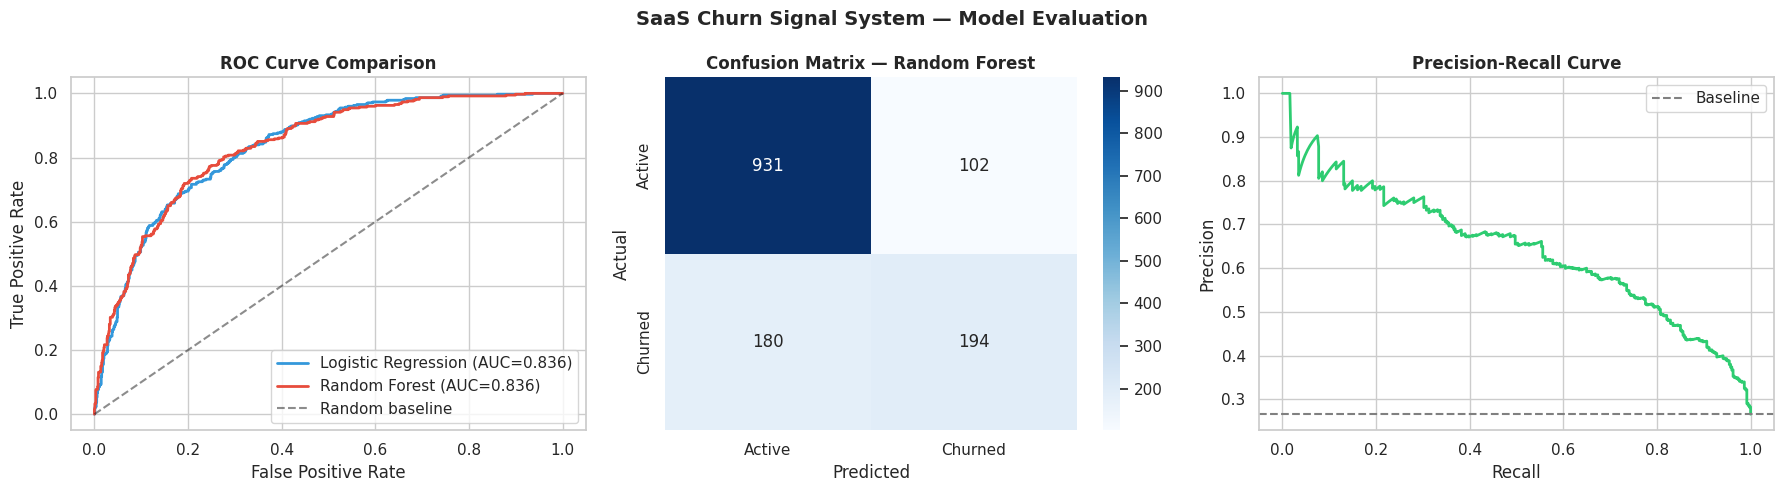


Confusion Matrix breakdown:
True Negatives  (correctly predicted active) : 931
False Positives (predicted churn, actually active) : 102
False Negatives (missed churners) : 180
True Positives  (correctly caught churners) : 194

Of 374 actual churners, we caught 194 (51.9%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
axes[0].plot(fpr_lr, tpr_lr, color='#3498db', linewidth=2,
             label=f'Logistic Regression (AUC={lr_auc:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
axes[0].plot(fpr_rf, tpr_rf, color='#e74c3c', linewidth=2,
             label=f'Random Forest (AUC={rf_auc:.3f})')

# Random baseline
axes[0].plot([0,1], [0,1], 'k--', alpha=0.5, label='Random baseline')
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# 5B — Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, rf_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix — Random Forest', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# 5C — Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_test, rf_pred_proba)
axes[2].plot(recall, precision, color='#2ecc71', linewidth=2)
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].axhline(y=y_test.mean(), color='gray',
                linestyle='--', label='Baseline')
axes[2].legend()

plt.suptitle('SaaS Churn Signal System — Model Evaluation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/10_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Read confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix breakdown:")
print(f"True Negatives  (correctly predicted active) : {tn}")
print(f"False Positives (predicted churn, actually active) : {fp}")
print(f"False Negatives (missed churners) : {fn}")
print(f"True Positives  (correctly caught churners) : {tp}")
print(f"\nOf {tp+fn} actual churners, we caught {tp} ({tp/(tp+fn)*100:.1f}%)")

# **SHAP Values**

Calculating SHAP values (may take 30-60 seconds)...


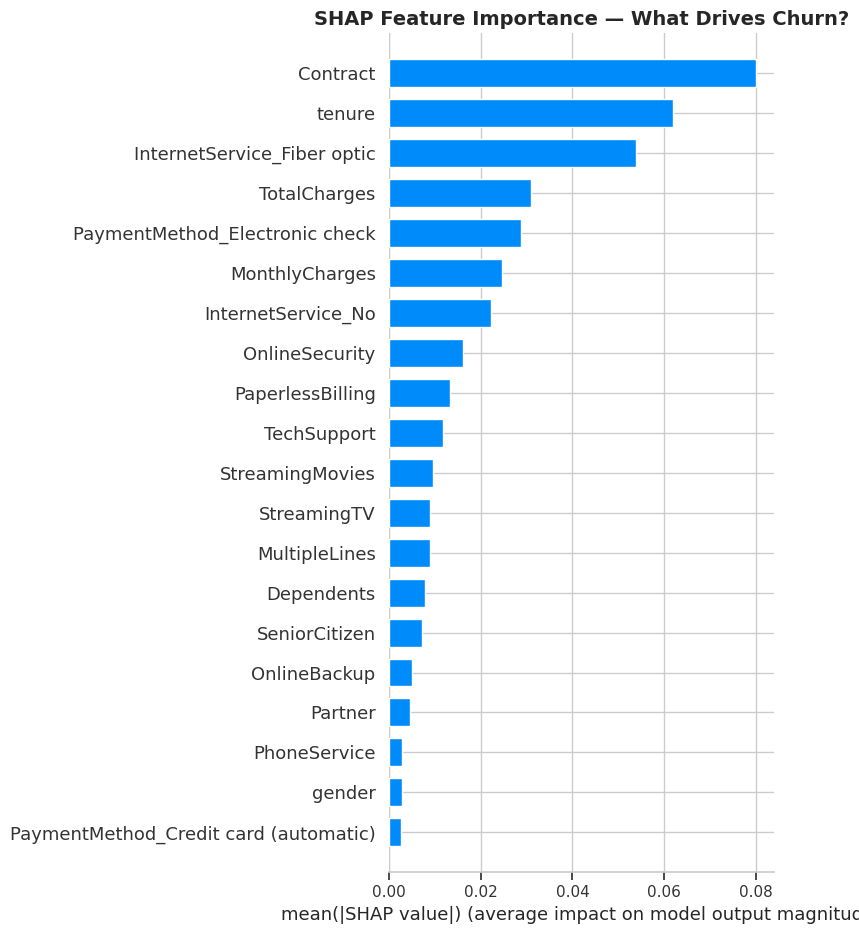

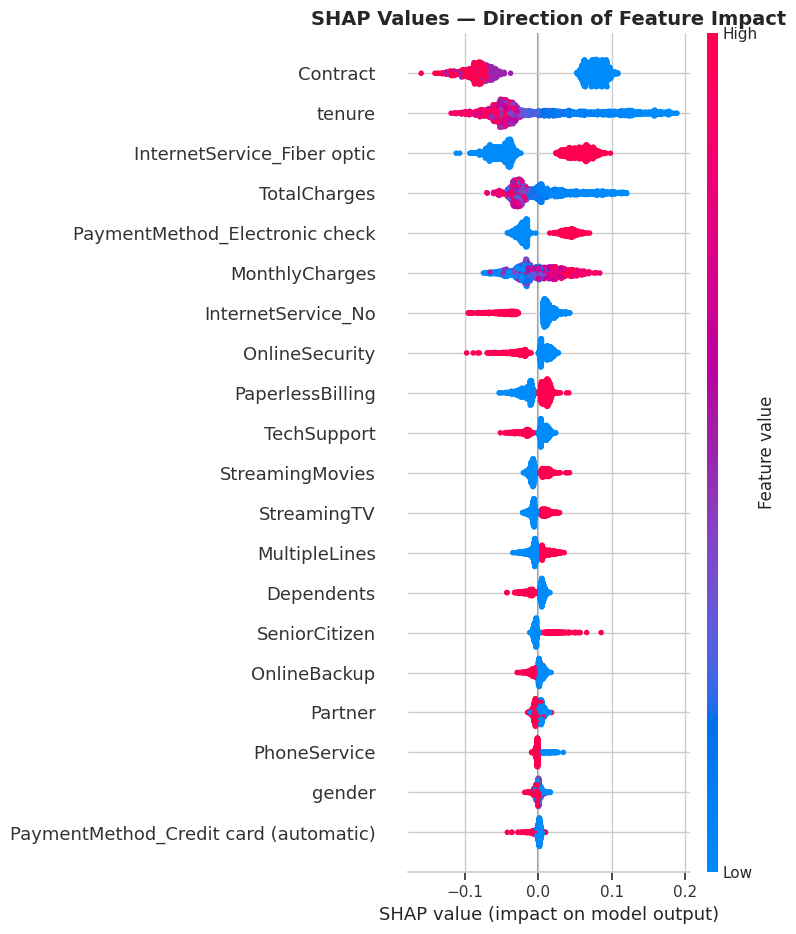


Top 5 churn drivers (by SHAP importance):
                           feature  importance
13                        Contract    0.079943
4                           tenure    0.061864
17     InternetService_Fiber optic    0.053876
16                    TotalCharges    0.030941
20  PaymentMethod_Electronic check    0.028728


In [ ]:
print("Calculating SHAP values (may take 30-60 seconds)...")

# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list of arrays or a 3D array.
# If shap_values is a 3D array (samples, features, classes), then get values for churn class (index 1)
# If shap_values is a list of 2D arrays, then get the second array (index 1)
# The kernel state shows shap_values as an ndarray of shape (1407, 22, 2)
shap_vals_churn = shap_values[:, :, 1]

# 6A — SHAP Summary Plot (feature importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_churn,
    X_test,
    feature_names=feature_cols,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — What Drives Churn?',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/11_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 6B — SHAP Beeswarm Plot (direction of impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_churn,
    X_test,
    feature_names=feature_cols,
    show=False
)
plt.title('SHAP Values — Direction of Feature Impact',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/12_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 churn drivers (by SHAP importance):")
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': np.abs(shap_vals_churn).mean(axis=0)
}).sort_values('importance', ascending=False)
print(shap_importance.head())

# **Score Every Customer**

In [ ]:
# Score all customers (not just test set)
X_all_scaled = scaler.transform(X)
all_proba    = rf_model.predict_proba(X)[:, 1]

# Build risk table
risk_table = df[['customerID', 'Contract', 'tenure',
                 'MonthlyCharges', 'Churn']].copy()
risk_table['Churn_Probability'] = all_proba.round(4)
risk_table['MRR_at_Risk'] = (
    risk_table['Churn_Probability'] * risk_table['MonthlyCharges']
).round(2)

# Risk tier labels
risk_table['Risk_Tier'] = pd.cut(
    risk_table['Churn_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Summary
print("CUSTOMER RISK SUMMARY")
print("="*45)
print(risk_table['Risk_Tier'].value_counts())
print(f"\nTotal MRR at Risk: ${risk_table['MRR_at_Risk'].sum():,.2f}")
print(f"\nTop 10 highest risk customers:")
print(risk_table.sort_values('Churn_Probability', ascending=False)
      [['customerID', 'Contract', 'tenure',
        'MonthlyCharges', 'Churn_Probability', 'Risk_Tier']]
      .head(10).to_string(index=False))

# Save for Power BI
risk_table.to_csv('customer_risk_scores.csv', index=False)
print("\nRisk scores saved to customer_risk_scores.csv")


CUSTOMER RISK SUMMARY
Risk_Tier
Low Risk       4315
Medium Risk    1846
High Risk       871
Name: count, dtype: int64

Total MRR at Risk: $138,880.75

Top 10 highest risk customers:
customerID  Contract  tenure  MonthlyCharges  Churn_Probability Risk_Tier
9497-QCMMS         0       1           93.55             0.9161 High Risk
9300-AGZNL         0       1           94.00             0.9161 High Risk
5178-LMXOP         0       1           95.10             0.9024 High Risk
3068-OMWZA         0       1           88.80             0.9012 High Risk
8149-RSOUN         0       1           93.85             0.8969 High Risk
4910-GMJOT         0       1           94.60             0.8954 High Risk
7024-OHCCK         0       2           93.85             0.8935 High Risk
0295-PPHDO         0       1           95.45             0.8921 High Risk
7660-HDPJV         0       1           69.20             0.8912 High Risk
9728-FTTVZ         0       1           69.20             0.8912 High Risk

Ris

In [ ]:
#Sonu